# Домашка №7 — DESeq2 и LIMMA

В этой работе разбираю два пайплайна поиска дифференциально экспрессированных генов:

- DESeq2 — для RNA-seq counts
- LIMMA — для микрочиповой экспрессии

Сначала DESeq2 на данных рака лёгкого (LuC) — пациенты на иммунотерапии (ICI), сравниваю отвечающих (R) и не отвечающих (NR). Потом LIMMA на датасете GSE63885 — рак яичников после химиотерапии, сравниваю pCR (полный ответ) и pNC (нет ответа).

---

# Часть 1. DESeq2

## Что за данные

Это bulk RNA-seq образцов рака лёгкого (LuC) пациентов, получавших ICI-терапию. В файле `raw_counts_ici_samples.tsv` лежит матрица raw counts (~37k генов × 28 образцов), статус ответа на терапию в `meta_responses.tsv` — R или NR. Аннотация Ensembl → HGNC берётся из `hgnc_complete_set.txt`.

Биологический вопрос: какие гены отличают пациентов, у которых иммунотерапия сработала, от тех, у кого нет. Это нужно для поиска биомаркёров.

## Что делаю

1. Отфильтровываю гены с суммарным числом ридов меньше 10.
2. Запускаю DESeq2 с моделью `~ X0` (X0 — статус R/NR, референс — NR).
3. Делаю VST-нормализацию для PCA и clustermap.
4. PCA — смотрю кластеризацию и есть ли выбросы / батч-эффект.
5. Clustermap — то же самое, но через евклидовы расстояния.
6. Считаю дифференциальную экспрессию (Wald test).
7. Аннотирую гены символами HGNC.
8. Порог значимости: padj < 0.05 и |log2FC| > 1.
9. Volcano plot.

### Код

In [1]:
!cat scripts/01_deseq2.R

library(DESeq2)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(pheatmap)

DATA <- "../data"
OUT  <- "../results/deseq2"
FIG  <- "../figures"
dir.create(OUT, showWarnings = FALSE, recursive = TRUE)
dir.create(FIG, showWarnings = FALSE, recursive = TRUE)

expr_raw <- read.csv(file.path(DATA, "raw_counts_ici_samples.tsv"), sep = "\t", row.names = 1)

meta <- read.csv(file.path(DATA, "meta_responses.tsv"), sep = "\t", row.names = 1)
meta <- meta %>% filter(X0 %in% c("R", "NR"))
rownames(meta) <- gsub("-", ".", rownames(meta))

expr_raw <- expr_raw[, rownames(meta)]
expr_raw <- expr_raw[rowSums(expr_raw) >= 10, ]
expr_raw <- round(expr_raw)

dds <- DESeqDataSetFromMatrix(countData = expr_raw, colData = meta, design = ~ X0)
dds$X0 <- relevel(dds$X0, ref = "NR")
dds <- DESeq(dds)

vsd <- vst(dds, blind = TRUE)
pca_data <- plotPCA(vsd, intgroup = "X0", returnData = TRUE)
percent_var <- round(100 * attr(pca_data, "percentVar"))

pca_data$short_name <- gsub("_.*", "", pca_data$name)
ce

## 1.1 PCA

PCA на VST-нормализованных counts, цветом — статус ответа.

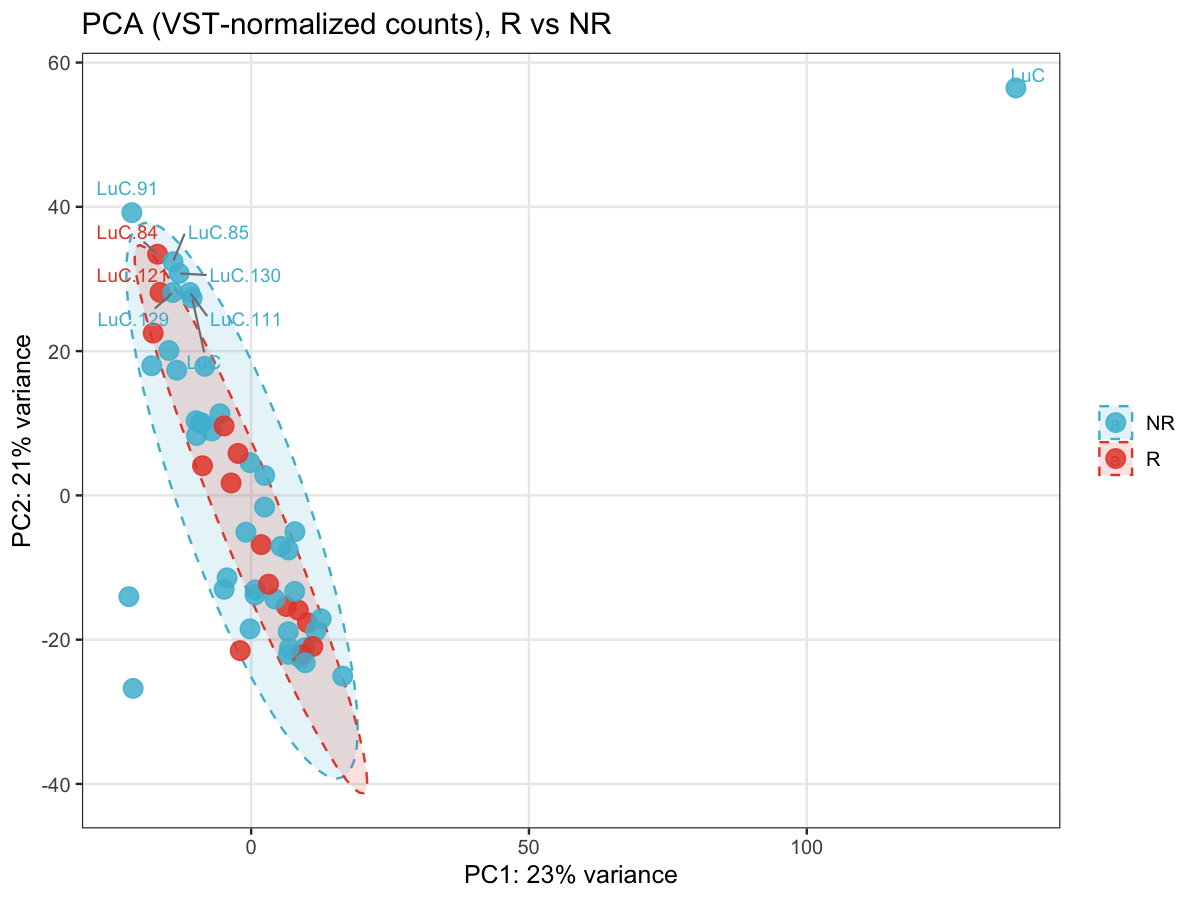

In [2]:
from IPython.display import Image
Image('figures/pca.png')

**Что вижу:**

Первая компонента (PC1) забирает 23% дисперсии, вторая 21% — в сумме 44%.

Сразу бросается в глаза один выброс справа сверху — образец LuC с PC1 ≈ 125, при том что все остальные сидят в диапазоне примерно от -30 до 25. Этот образец один тянет всю шкалу первой компоненты. Ещё пара NR-образцов слева внизу выбиваются слабее.

В основном облаке точки R и NR перемешаны — никакой явной двукластерной структуры. 



### Удалять ли выброс

Аргументы за удаление: искажает шкалу PCA, может смещать дисперсию в DESeq2.
Аргументы против: DESeq2 сам устойчив к выбросам — он использует Cook's distance и автоматически выбрасывает гены, у которых результат держится на одной точке. К тому же у меня нет технического обоснования (низкая глубина, плохое качество), чтобы выкидывать образец вручную.

Для проверки построил PCA после удаления:

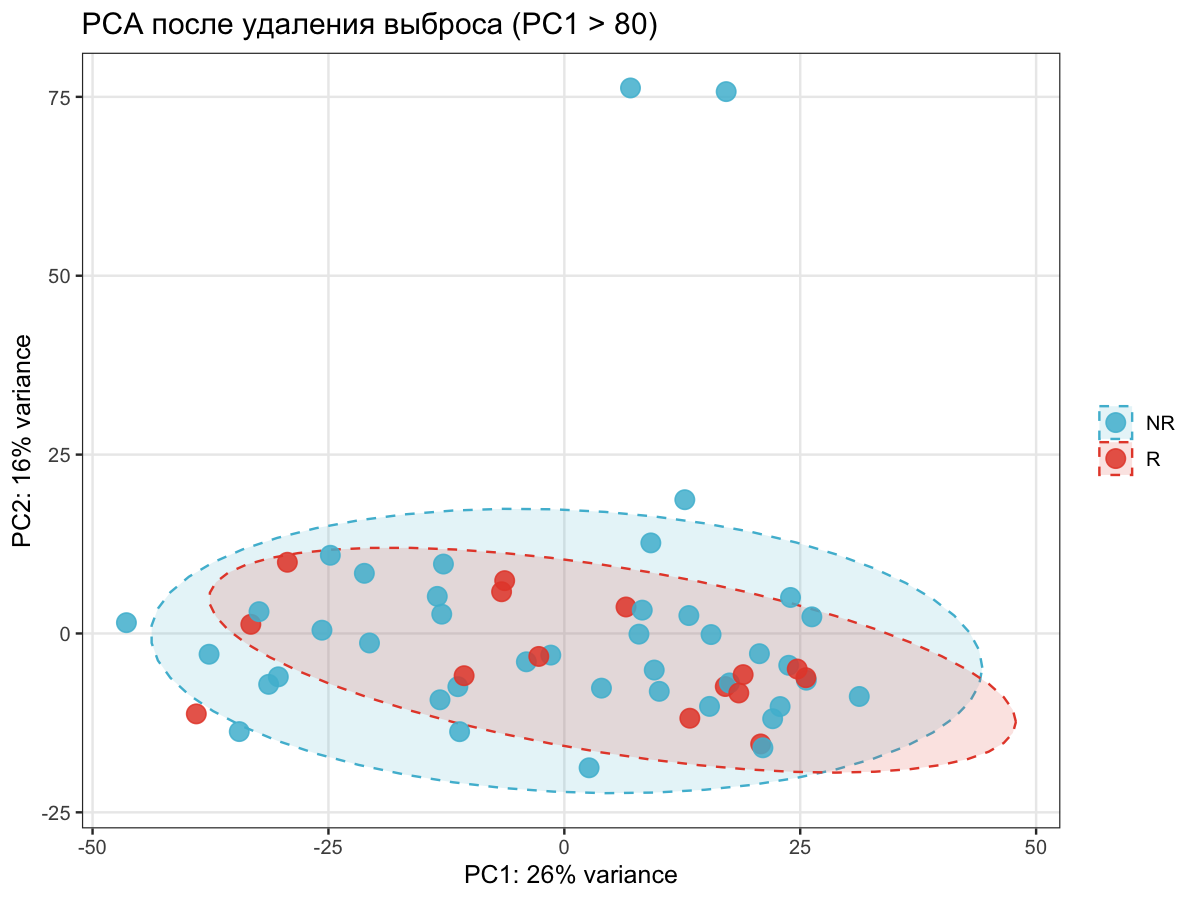

In [3]:
Image('figures/pca_no_outlier.png')

Без выброса PC1 объясняет уже 26%, PC2 — 16%. Эллипсы групп почти полностью накладываются — то есть **глобально R и NR не различаются**, разница будет видна только в отдельных генах. Картина качественно та же, что и до удаления.

Поэтому в основном анализе оставляю все образцы — DESeq2 сам разберётся.

## 1.2 Clustermap

Матрица евклидовых расстояний между образцами на VST-данных, иерархическая кластеризация. Сверху — аннотация по статусу ответа.

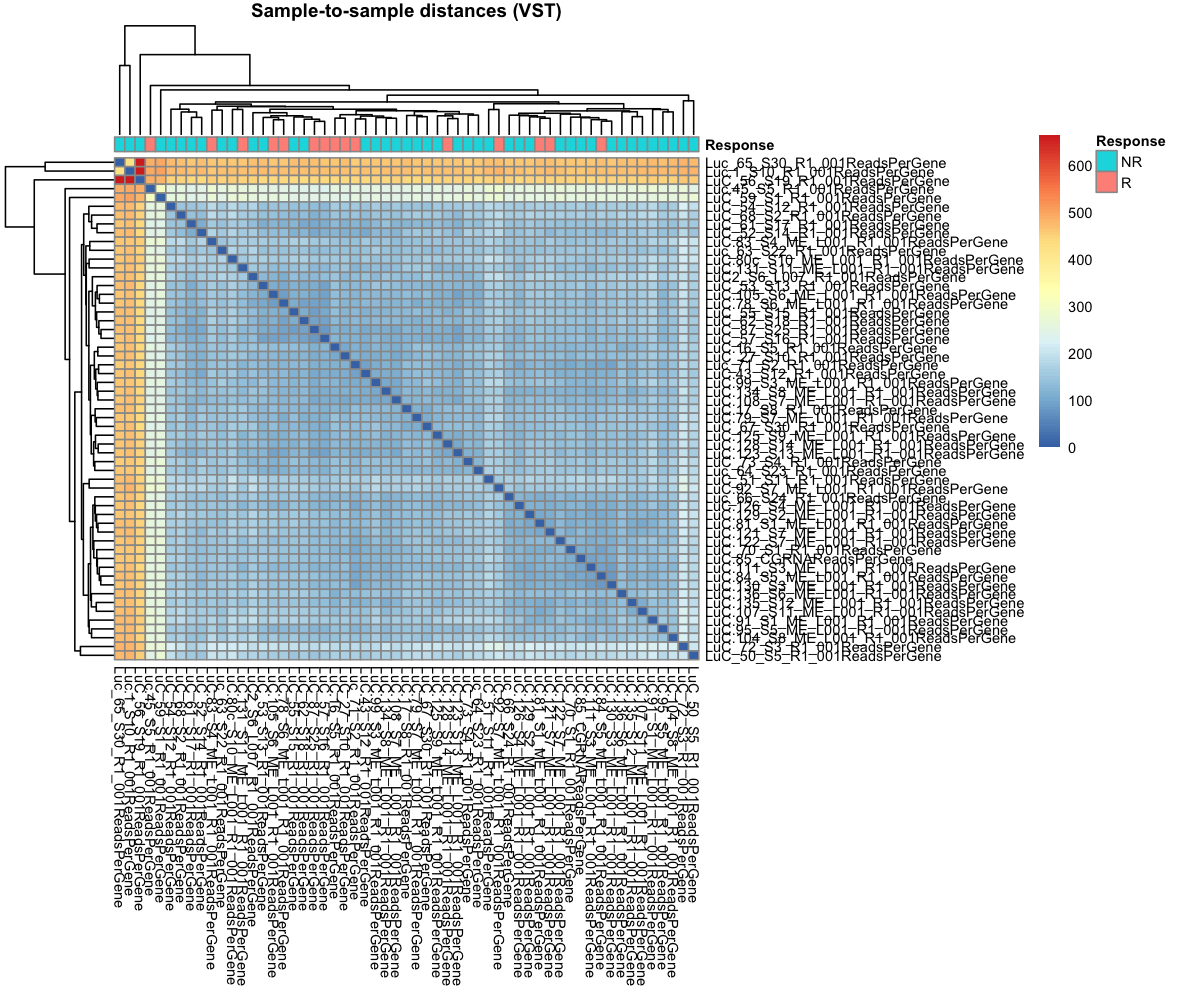

In [4]:
Image('figures/clustermap.png')

**Что вижу:**

Дерево кластеризации не делит образцы на два чистых блока по статусу — R и NR перемешиваются на разных уровнях. Тот же вывод, что и из PCA: глобально транскриптомы между группами не отличаются.

Никаких больших однородных квадратов, которые бы говорили о батч-эффекте, на матрице нет.

## 1.3 Поиск DEG

Таблица с результатами DESeq2: log2FC, p-value, скорректированное p-value (BH), флаг significant (padj < 0.05 и |log2FC| > 1).

In [5]:
import pandas as pd
deseq = pd.read_csv('results/deseq2/deseq2_results.csv')
print(f"Всего генов протестировано: {len(deseq)}")
print(f"Значимых (padj<0.05, |log2FC|>1): {(deseq['significant']=='Significant').sum()}")
print(f"  выше в R:  {((deseq['significant']=='Significant') & (deseq['log2FoldChange']>0)).sum()}")
print(f"  выше в NR: {((deseq['significant']=='Significant') & (deseq['log2FoldChange']<0)).sum()}")
deseq.head(20)

Всего генов протестировано: 41371
Значимых (padj<0.05, |log2FC|>1): 190
  выше в R:  20
  выше в NR: 170


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl_id,gene_symbol,significant
0,26.448681,-24.416750,3.319016,-7.356624,1.886195e-13,4.583831e-09,ENSG00000236878,MTATP6P26,Significant
1,5.694160,-22.295683,3.320295,-6.714971,1.881041e-11,1.539993e-07,ENSG00000274721,ENSG00000274721,Significant
2,5.464485,-22.243124,3.320334,-6.699062,2.097609e-11,1.539993e-07,ENSG00000279336,ENSG00000279336,Significant
3,5.154743,-22.151491,3.320395,-6.671341,2.534760e-11,1.539993e-07,ENSG00000267563,ENSG00000267563,Significant
4,5.880678,-22.010753,3.320265,-6.629216,3.374748e-11,1.640263e-07,ENSG00000266987,ENSG00000266987,Significant
5,4.882293,-21.739271,3.320456,-6.547074,5.867529e-11,2.376545e-07,ENSG00000230585,PHBP12,Significant
6,32.800080,-6.046700,0.978458,-6.179828,6.417163e-10,2.227856e-06,ENSG00000259370,ENSG00000259370,Significant
7,99.388655,-5.582263,0.987902,-5.650625,1.598653e-08,4.856309e-05,ENSG00000204539,CDSN,Significant
8,41.140438,-5.230303,0.934946,-5.594228,2.216057e-08,5.983846e-05,ENSG00000245156,ENSG00000245156,Significant
9,114.798608,-10.826200,1.944325,-5.568102,2.575295e-08,6.258483e-05,ENSG00000159516,SPRR2G,Significant


## 1.4 Volcano plot

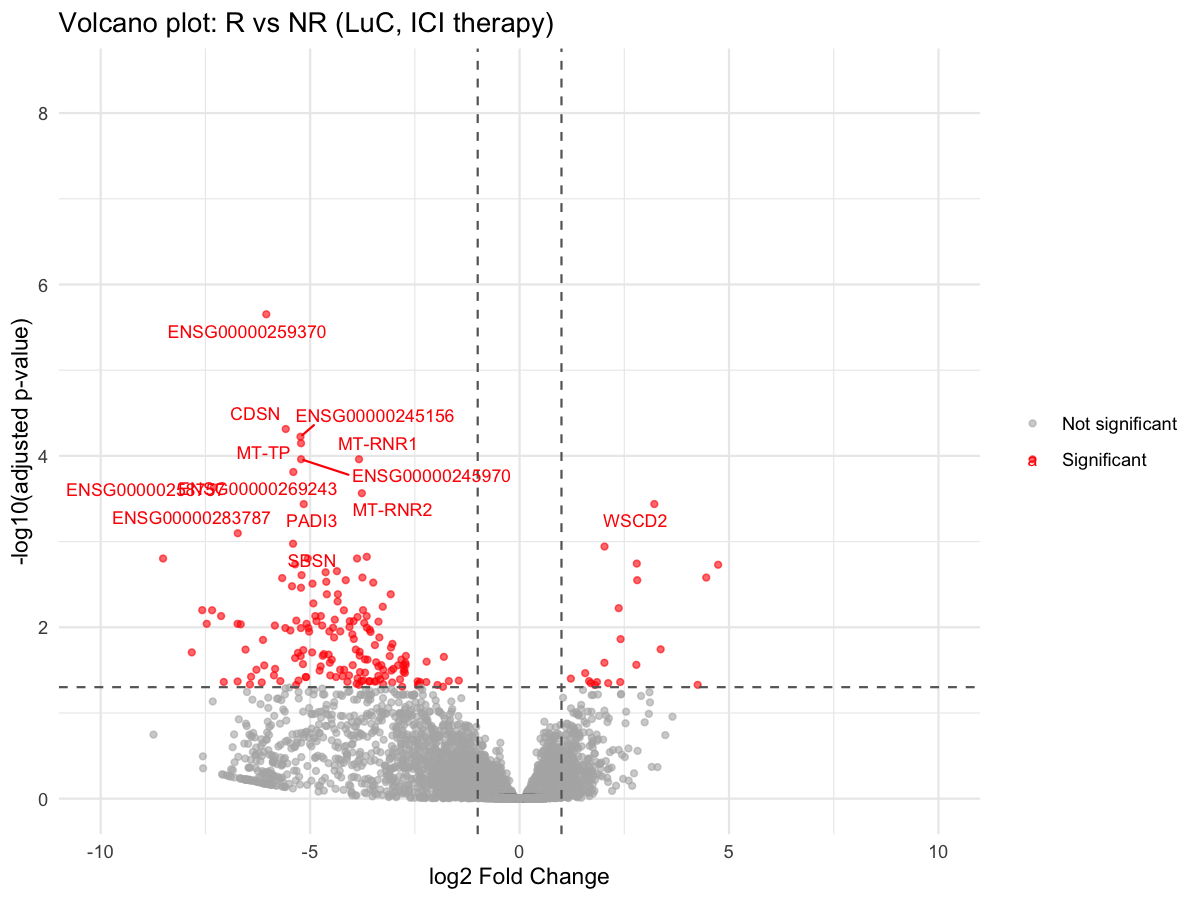

In [6]:
Image('figures/volcano_deseq2.png')

## 1.5 Выводы по Части 1

PCA и clustermap показали, что глобально R и NR не отличаются. Один явный выброс есть, но не удалял — DESeq2 справится через Cook's distance.

Явных батч-эффектов нет, поэтому использовал самый простой дизайн `~ X0`.

При пороге padj < 0.05 и |log2FC| > 1 нашлось 190 значимых генов: 20 выше в группе R, 170 выше в NR. Список лежит в `results/deseq2/deseq2_significant.csv` — это кандидаты для последующего обогащения (GSEA, hallmark-сигнатуры, иммунно-связанные пути).

### Код

In [7]:
!cat scripts/02_limma.R

library(limma)
library(ggplot2)
library(ggrepel)

DATA <- "../data/GSE63885"
OUT  <- "../results/limma"
FIG  <- "../figures"
dir.create(OUT, showWarnings = FALSE, recursive = TRUE)
dir.create(FIG, showWarnings = FALSE, recursive = TRUE)

exp <- read.csv(file.path(DATA, "expression_for_limma2.csv"),
                header = TRUE, row.names = "Gene.Symbol")
ann <- read.csv(file.path(DATA, "annotation_for_limma.csv"),
                header = TRUE, row.names = "X")

stopifnot(all(rownames(ann) == colnames(exp)))

col_status <- "clinical.status.post.1st.line.chemotherapy..cr...complete.response..pr...partial.response..sd...stable.disease..p...progression..ch1"
slope <- factor(ann[[col_status]], levels = c("pCR", "pNC"), labels = c(1, 0))
pCR <- as.integer(as.vector(slope))

keep <- !is.na(pCR)
exp <- exp[, keep]
ann <- ann[keep, ]
pCR <- pCR[keep]

cat("Samples after filtering: pCR =", sum(pCR == 1), ", pNC =", sum(pCR == 0), "\n")

design <- cbind(npCR = rep(1, length(pCR)), pCR = pCR)
fi

## 2.1 Сколько значимых генов при разных logFC

In [8]:
counts = pd.read_csv('results/limma/limma_significance_counts.csv')
counts

,logFC_threshold,significant_genes,up_in_pCR,up_in_pNC
0,1,67,25,42
1,2,4,2,2
2,3,0,0,0


## 2.2 Таблица с тремя столбцами significance

In [9]:
limma = pd.read_csv('results/limma/limma_results.csv')
limma[['gene_symbol','logFC','AveExpr','t','P.Value','adj.P.Val','significant_logFC1','significant_logFC2','significant_logFC3']].head(20)

,gene_symbol,logFC,AveExpr,t,P.Value,adj.P.Val,significant_logFC1,significant_logFC2,significant_logFC3
0,ZSCAN18,0.737513,8.430347,4.354984,0.000081,0.353827,Not significant,Not significant,Not significant
1,MYOM1,-1.074808,6.970136,-4.311937,0.000093,0.353827,Significant,Not significant,Not significant
2,CDC14B,-0.670027,6.888196,-4.065375,0.000201,0.509022,Not significant,Not significant,Not significant
3,CTSC,-1.074529,8.819765,-3.852655,0.000386,0.546576,Significant,Not significant,Not significant
4,SUPT16H,-1.485898,9.676106,-3.795390,0.000459,0.546576,Significant,Not significant,Not significant
5,TUBA3C,-0.637371,8.525479,-3.788841,0.000468,0.546576,Not significant,Not significant,Not significant
6,SREK1,-0.735790,6.610824,-3.763794,0.000504,0.546576,Not significant,Not significant,Not significant
7,KRT18,-0.938353,12.696659,-3.616409,0.000782,0.666113,Not significant,Not significant,Not significant
8,BTG3,1.626014,8.769851,3.599486,0.000822,0.666113,Significant,Not significant,Not significant
9,PON2,-1.054841,9.524526,-3.572806,0.000889,0.666113,Significant,Not significant,Not significant


## 2.3 Volcano-плоты для каждого logFC

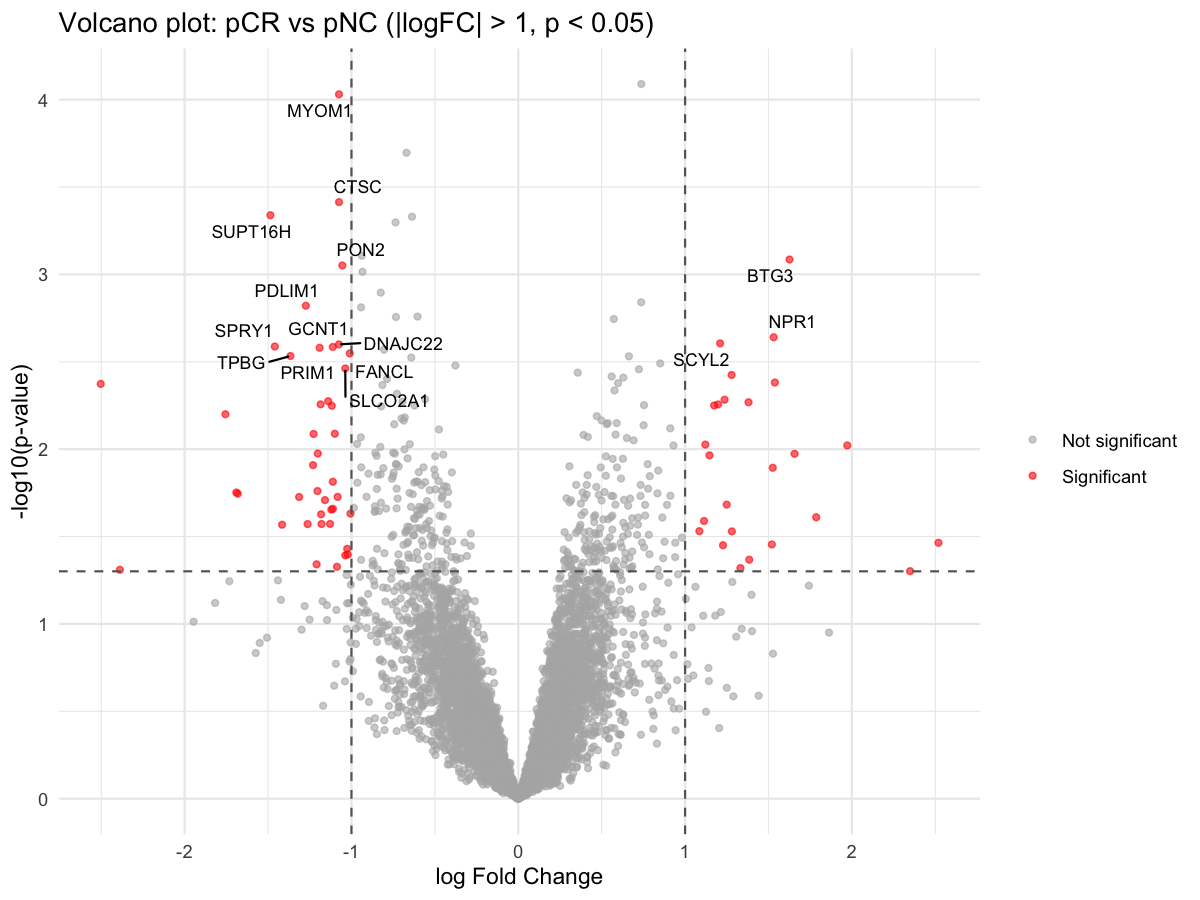

In [10]:
Image('figures/volcano_limma_logFC1.png')

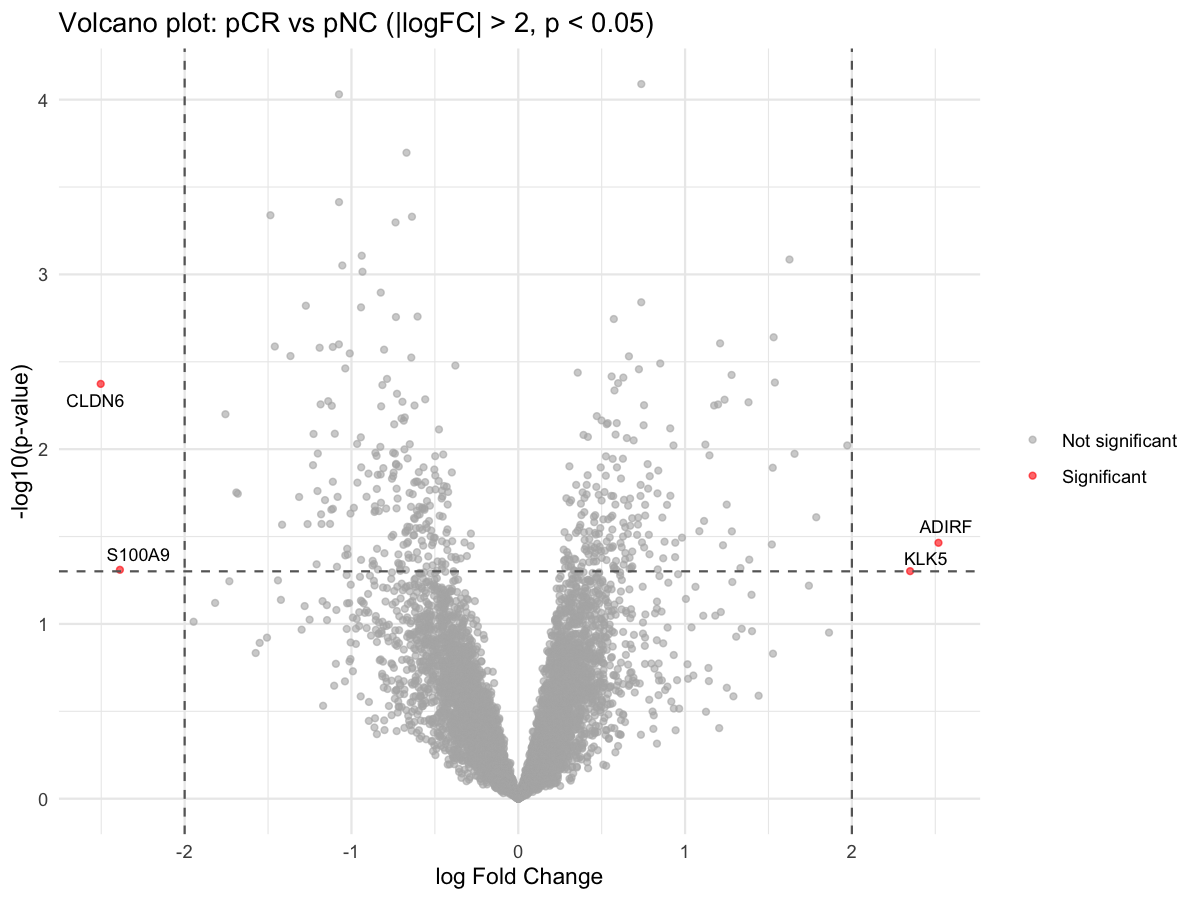

In [11]:
Image('figures/volcano_limma_logFC2.png')

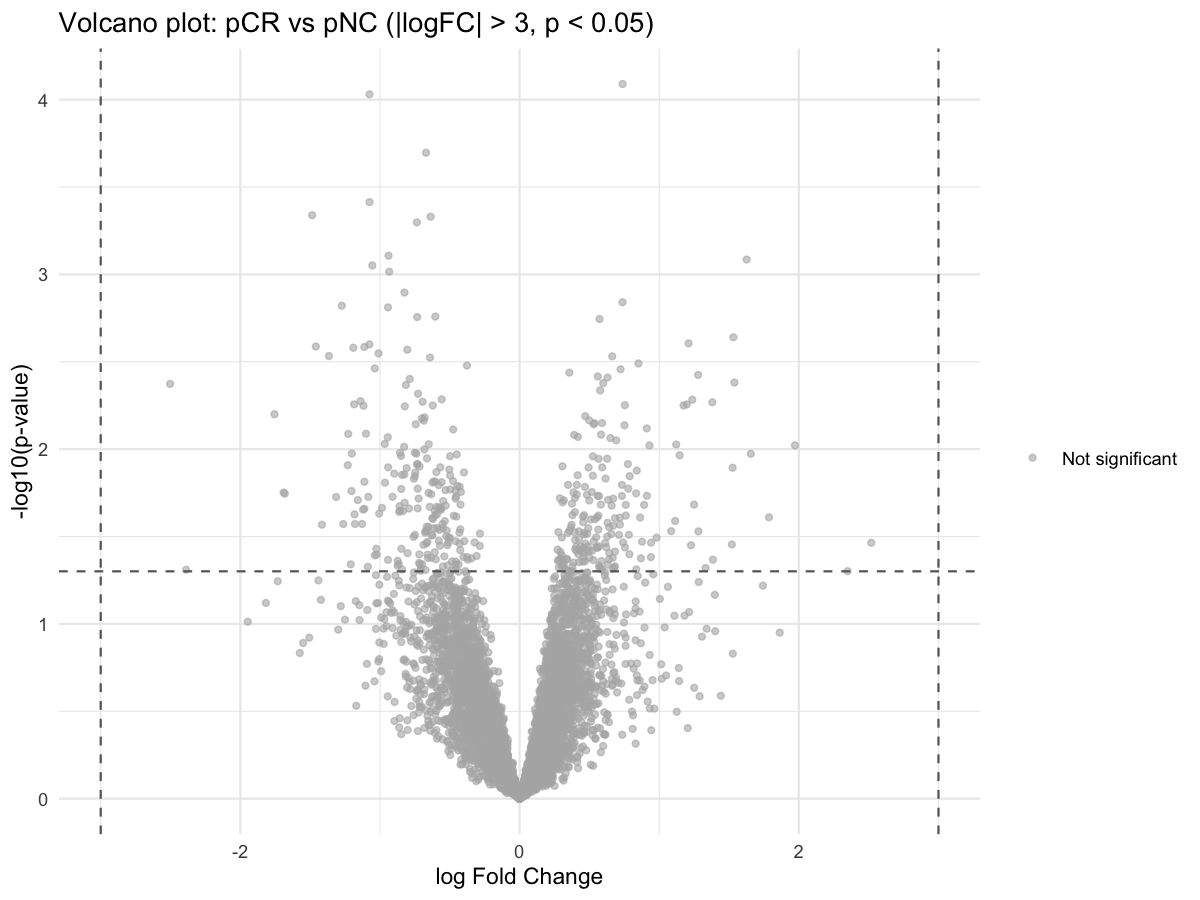

In [12]:
Image('figures/volcano_limma_logFC3.png')

## 2.4 Какой logFC выбрать

Тут важная деталь: когорта сильно несбалансирована — 39 pCR против 2 pNC. По двум образцам дисперсию pNC оценить нормально нельзя, поэтому BH-поправка получается слишком жёсткой: при padj < 0.05 не остаётся ни одного гена, хотя по nominal p-value сотни генов отличаются.

Поэтому в качестве порога значимости я взял nominal P.Value < 0.05. Это типичная практика для маленьких/несбалансированных микрочиповых выборок, когда задача — отобрать кандидатов для дальнейшего обогащения, а не делать строгий статистический вывод.

С таким порогом получилось:

- logFC > 1 → 67 генов (2-кратное и более изменение)
- logFC > 2 → 4 гена (4-кратное)
- logFC > 3 → 0 генов (8-кратное)

На микрочипах динамический диапазон сжат — 8-кратные различия там почти не встречаются, поэтому logFC > 3 даёт пустой список. logFC > 2 оставляет всего 4 гена — для обогащения этого мало.

**Беру logFC > 1**: 67 генов — нормальный список для последующего GSEA, не слишком жёстко и не слишком мягко.

## 2.5 Выводы по Части 2

LIMMA — правильный выбор для микрочиповых данных GSE63885, DESeq2 здесь неприменим.

Когорта несбалансирована (39:2), поэтому BH-поправка слишком консервативна — в качестве порога взял nominal p < 0.05.

С ужесточением logFC количество значимых генов падает: 67 → 4 → 0. Оптимальный порог для этого датасета — logFC = 1.

## Что в итоге

| | DESeq2 | LIMMA |
|---|---|---|
| Тип входа | counts | log-intensities |
| Модель | negative binomial | linear + emp. Bayes |
| Нормализация | size factors внутри | вход уже нормализован |
| Где применять | RNA-seq | микрочипы, voom-RNA-seq, протеомика |